In [87]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect("/Users/nicolestofenmacher/Downloads/dimspec_nist_pfas.sqlite")
cursor = conn.cursor()

# 1. Database Exploration

## 1.1 Overall Database Structure

## 1.2 Relevant Tables

## 1.3 Relationships Between Tables

## 1.4 Compound Naming Conventions

## 1.1: Explore the overall structure of the NIST PFAS database.

Research Question: What information is contained within the NIST PFAS database, and which tables are relevant to PFAS characterization?

Purpose: Before analyzing PFAS compounds or their mass spectral signatures, it is necessary to understand how the database is organized. The first step is to identify the tables contained within the SQLite database and determine which ones are relevant to answering the research objectives.

In [88]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

for row in cursor.fetchall():
    print(row)

('config',)
('elements',)
('sqlite_sequence',)
('isotopes',)
('norm_ionization',)
('norm_carriers',)
('norm_additives',)
('norm_vendors',)
('norm_ce_desc',)
('norm_ce_units',)
('norm_voltage_units',)
('norm_ms_types',)
('norm_ms_n_types',)
('norm_fragmentation_types',)
('norm_polarity_types',)
('norm_chromatography_types',)
('norm_column_chemistries',)
('norm_column_positions',)
('norm_duration_units',)
('norm_additive_units',)
('norm_flow_units',)
('carrier_mix_collections',)
('mobile_phases',)
('ms_descriptions',)
('chromatography_descriptions',)
('ms_methods',)
('carrier_aliases',)
('additive_aliases',)
('carrier_mixes',)
('carrier_additives',)
('norm_generation_type',)
('norm_source_types',)
('compound_categories',)
('norm_analyte_alias_references',)
('compounds',)
('compound_aliases',)
('compound_fragments',)
('annotated_fragments',)
('fragment_inspections',)
('norm_fragments',)
('fragment_aliases',)
('fragment_sources',)
('norm_sample_classes',)
('norm_ion_states',)
('norm_peak_c

Results: 
The query returned over sixty tables. The most relevant for this project were identified as: samples, compounds, peaks, compound_fragments, ms_data,annotated_fragments
    

Interpretation: 
The NIST PFAS database is organized as a relational database, meaning that different types of information are stored separately and connected through common identifiers. Rather than storing all information in a single table, the database separates sample information, compound identities, chromatographic peaks, and mass spectral data into individual tables.

Key Takeaway: The database contains all the information necessary to characterize PFAS samples, but the data are distributed across multiple related tables that must later be connected using SQL joins.

## 1.2: Characterize the Relevant Tables

Research question: What chemical information is stored for each compound in the database, and how extensive is the compound reference library?

Purpose: The compounds table was examined to understand the chemical reference information available within the NIST PFAS database. In addition to inspecting representative entries, the total number of compounds was determined to characterize the scope of the reference library.

In [89]:
cursor.execute("""
SELECT id, name, formula, fixedmass
FROM compounds
LIMIT 10;
""")

for row in cursor.fetchall():
    print(row)

(1, '1H-Perfluoro-3,3-bis(trifluoromethyl)hexyne', 'C8HF13', 343.9870669)
(2, 'Bis(heneicosafluorodecyl)phosphinic acid', 'C20H9F34O2P', 957.9797256)
(3, 'Tris(2-(perfluorododecyl)ethyl)phosphate', 'C42H12F75O4P', 2035.927562)
(4, '2-Chloro-2-propenoic acid 3,3,4,4,5,5,6,6,6-nonafluorohexyl ester', 'C9H6ClF9O2', 351.9912611)
(5, 'Bicyclo[2.2.1]hept-2-ene, 5,5,6-trifluoro-6-(heptafluoropropoxy)-', 'C10H6F10O', 332.025897)
(6, '3,3,4-Trifluoro-4-(heptafluoropropoxy)tricyclo[4.2.1.0~2,5~]non-7-ene', 'C12H8F10O', 358.0415471)
(7, '5-(Nonafluorobutyl)bicyclo[2.2.1]hept-2-ene', 'C11H9F9', 312.0560543)
(8, '3-(Heptafluorobutyryl)camphor', 'C14H15F7O2', 348.0960273)
(9, 'Perfluorobutylsulfonamide', 'C4H2F9NO2S', 298.9662533)
(10, 'N-(3,4-Dichlorophenyl)-2,2,3,3,4,4,4-heptafluorobutanamide', 'C10H4Cl2F7NO', 356.9558166)


Results: 
The first ten entries included fluorinated compounds such as:
    1H-Perfluoro-3,3-bis(trifluoromethyl)hexyne
    Bis(heneicosafluorodecyl)phosphinic acid
    Tris(2-(perfluorododecyl)ethyl)phosphate
    Perfluorobutylsulfonamide

Each entry included their unique compound ID, chemical name, molecular formula, andexact (monoisotopic) mass

Interpretation: The **compounds** table functions as a reference library rather than experimental data. Each row represents a unique fluorinated compound and provides the molecular information required for compound identification. The diversity of compounds indicates that the database includes not only common PFAS but also precursor compounds and other fluorinated substances.

Key takeaway: The compounds table provides the chemical identities that will later be linked to experimental observations in the LC-MS/MS data.

In [90]:
cursor.execute("""
SELECT COUNT(*)
FROM compounds;
""")

print(f"Total compounds: {cursor.fetchone()[0]}")

Total compounds: 4967


Results: The compounds table functions as a chemical reference library rather than a table of experimental observations. Each row corresponds to a unique fluorinated compound and provides the molecular information required for compound identification, including its chemical name, molecular formula, and exact (monoisotopic) mass. With 4,967 unique compounds, the database extends far beyond the limited number of PFAS typically targeted in routine analytical methods (e.g., EPA Method 1633). This comprehensive reference library includes a wide range of fluorinated compounds and potential precursors, making it well suited for computational analyses and future AI/ML applications aimed at identifying both known and emerging PFAS.

Key takeaways: The compounds table serves as the chemical foundation of the NIST PFAS database, providing a comprehensive reference library of 4,967 compounds that can be linked to experimental LC-MS/MS measurements for downstream characterization, comparative analysis, and AI-assisted PFAS identification.

## 1.3: Determine relationships between tables

Research question: How are the relevant tables related, and how can these relationships be used to integrate sample, compound, and LC-MS/MS information?

Purpose: The foreign key relationships among the relevant tables were examined to determine how different types of information are connected within the NIST PFAS database. Understanding these relationships is essential for constructing SQL JOIN statements that combine sample metadata, chromatographic peaks, compound identities, and mass spectral information.

In [91]:
cursor.execute("PRAGMA foreign_key_list(peaks);")

for row in cursor.fetchall():
    print(row)

(0, 0, 'norm_peak_confidence', 'identification_confidence', 'id', 'CASCADE', 'RESTRICT', 'NONE')
(1, 0, 'norm_ion_states', 'ion_state', 'id', 'CASCADE', 'RESTRICT', 'NONE')
(2, 0, 'conversion_software_peaks_linkage', 'conversion_software_peaks_linkage_id', 'id', 'CASCADE', 'RESTRICT', 'NONE')
(3, 0, 'samples', 'sample_id', 'id', 'CASCADE', 'CASCADE', 'NONE')


Results: The sample_id column inside the peaks table points to the id column inside the samples table.

| Table   | Column      | Connects To  |
| ------- | ----------- | ------------ |
| `peaks` | `sample_id` | `samples.id` |

Each row in the peaks table contains a sample_id, which identifies the sample from which that chromatographic peak was detected.

In [92]:
cursor.execute("PRAGMA foreign_key_list(compound_fragments);")

for row in cursor.fetchall():
    print(row)

(0, 0, 'annotated_fragments', 'annotated_fragment_id', 'id', 'CASCADE', 'CASCADE', 'NONE')
(1, 0, 'compounds', 'compound_id', 'id', 'CASCADE', 'SET NULL', 'NONE')
(2, 0, 'peaks', 'peak_id', 'id', 'CASCADE', 'CASCADE', 'NONE')


Results: 
The compound_fragments table contains three linking columns:

| Table                | Linking Column          | References               |
| -------------------- | ----------------------- | ------------------------ |
| `compound_fragments` | `peak_id`               | `peaks.id`               |
| `compound_fragments` | `compound_id`           | `compounds.id`           |
| `compound_fragments` | `annotated_fragment_id` | `annotated_fragments.id` |

The compound_fragments table acts as a bridge between chromatographic peaks and compound identities. Each record links a detected peak to a specific compound and, when available, to its corresponding annotated fragment information. This table is therefore central to identifying which compounds are associated with the detected LC-MS/MS peaks.

Why does this matter? Notice the progression now:
    samples → Where did the data come from?
    
    peaks → What signals were detected?
    
    compound_fragments → Which compounds do those signals correspond to?
    
    ms_data → What does the detailed mass spectrum of each signal look like?


In [93]:
cursor.execute("PRAGMA foreign_key_list(ms_data);")

for row in cursor.fetchall():
    print(row)

(0, 0, 'peaks', 'peak_id', 'id', 'CASCADE', 'CASCADE', 'NONE')


The ms_data table contains a peak_id column that links each mass spectral measurement to its corresponding chromatographic peak in the peaks table.

| Table     | Linking Column | References |
| --------- | -------------- | ---------- |
| `ms_data` | `peak_id`      | `peaks.id` |

This relationship allows the detailed mass spectral measurements stored in the ms_data table to be associated with the chromatographic peak from which they were generated. As a result, each detected peak can be connected to its corresponding LC-MS/MS spectral information for further analysis.

## 1.4 Compound Naming Convention

Purpose: Determine how PFAS compounds are represented in the database.

In [94]:
cursor.execute("""
SELECT name
FROM compounds
WHERE name LIKE '%PF%'
LIMIT 30;
""")

for row in cursor.fetchall():
    print(row)

('Hydrogen-substituted perfluoro 3,6-dioxaoctane sulfonic acid (H-PFO2OS)',)
('Hydrogen-substituted perfluoro 3,6-dioxadecane sulfonic acid (H-PFO2DS)',)
('Hydrogen-substituted perfluoro 3,6-dioxanonane sulfonic acid (H-PFO2NS)',)


Results: Only three compounds were returned:
    H-PFO2OS
    H-PFO2DS
    H-PFO2NS

Interpretation: Searching for the string "PF" identified very few compounds, indicating that the database primarily stores compounds using systematic chemical names rather than common PFAS abbreviations such as PFOS or PFOA. Consequently, identifying PFAS compounds cannot rely solely on text-based searches and instead requires linking compounds to experimental observations through relational queries.

Key Takeaway: PFAS compounds are primarily represented by systematic nomenclature, making relational database queries more appropriate than simple keyword searches.

# 2 DATABASE CHARACTERIZATION


## 2.1. Extract PFAS sample information

## 2.2 Characterize the PFAS dataset

## 2.3 Mass Spectral Characterization

## 2.1: Extract PFAS sample information

Research question: Which PFAS compounds are associated with each sample, and what experimental information can be retrieved by linking the relevant tables?

Purpose: The relationships identified in the previous section were used to join the samples, peaks, compound_fragments, and compounds tables. This allowed the retrieval of sample names, identified compounds, and their corresponding precursor ion (MS¹) masses.

In [95]:
cursor.execute("""
SELECT DISTINCT
    s.description AS sample,
    c.name AS compound,
    p.precursor_mz
FROM samples s
JOIN peaks p
ON s.id = p.sample_id
JOIN compound_fragments cf
ON p.id = cf.peak_id
JOIN compounds c
ON cf.compound_id = c.id
LIMIT 20;
""")

for row in cursor.fetchall():
    print(row)

('3M 1989 AFFF', 'N-Hydroxyethyldimethylammoniopropyl perfluorohexanesulfonamide', 529.0815)
('3M 1989 AFFF', 'N-Trimethylammoniopropyl perfluorohexane sulfonamide', 499.0714)
('3M 1989 AFFF', 'N-Hydroxyethyldimethylammoniopropyl perfluorohexanesulfonamidoethanol', 573.1061)
('3M 1993a AFFF', 'N-Dimethyl ammonio propyl perfluoropropane sulfonamido propanoic acid', 407.0863)
('3M 1993a AFFF', '3-(N-(3-(dimethylamino)propyl)-perfluoropentylsulfonamido)propanoic acid', 507.0788)
('3M 1993a AFFF', 'N-Trimethylammoniopropyl perfluorohexane sulfonamido propanoic acid', 571.0906)
('3M 1993a AFFF', 'N-[3-(Dimethylamino)propyl]-N-[(tridecafluorohexyl)sulfonyl]-beta-alanine', 557.0744)
('3M 1993a AFFF', 'N-[3-(Dimethylamino)propyl]-N-[(nonafluorobutyl)sulfonyl]-beta-alanine', 457.0823)
('3M 1993a AFFF', 'Perfluoropentane sulfonamido amine', 435.0581)
('3M 1993b AFFF', 'N-Dimethyl ammonio propyl perfluoropropane sulfonamido propanoic acid', 407.0863)
('3M 1993b AFFF', '3-(N-(3-(dimethylamino)prop

Results: 
The SQL JOIN successfully linked information stored across four tables. For each detected compound, the query returned:
    - The sample in which the compound was detected
    - The identified compound name
    - The corresponding precursor ion mass-to-charge ratio (precursor_mz)

The output shows that individual samples contain multiple detected PFAS compounds. For example, the sample 3M 1989 AFFF contains compounds such as Perfluorooctanesulfonic acid (PFOS), Perfluorooctanoic acid (PFOA), Perfluorohexanesulfonic acid (PFHxS), and several fluorotelomer- and sulfonamide-related compounds, each with its associated precursor ion mass. Similar patterns are observed for other AFFF formulations, including 3M 1993a AFFF, 3M 1998 AFFF, and National Foam AFFF.


Interpretation: The successful JOIN demonstrates that the relational structure of the NIST PFAS database can be used to integrate sample information, compound identities, and experimental LC-MS/MS measurements. Rather than storing all information in a single table, the database links multiple tables together, allowing each detected chromatographic peak to be associated with both its originating sample and its identified compound. This integrated structure provides the foundation for subsequent analyses of PFAS occurrence and mass spectral characteristics.

Key Takeaway: The SQL JOIN confirms that the database can successfully retrieve integrated information across multiple tables, linking each sample to its detected PFAS compounds and their corresponding precursor ion masses. This demonstrates that the database is organized to support comprehensive characterization of PFAS detected by LC-MS/MS.

## 2.2 Characterize the PFAS dataset

### 2.2.1 How many unique samples are there?
    
### 2.2.2 How many compounds were identified in each sample?
    
### 2.2.3 Which PFAS compounds occur most frequently in the database?
    
### 2.2.4 What does an individual environmental sample look like?
    
#### a) Compounds identified
#### b) Precursor m/z and Retention-Time profile
#### c) Short- and Long-Chain PFAS Composition
    
### 2.2.5 Sample-Level Feature Table

### 2.2.6 Construct a Sample–Compound Feature Matrix

### 2.2.7 Compound co-occurrence

### 2.2.8 Composition by Sample Class

### 2.2.1 How many unique samples are there?

In [96]:
cursor.execute("SELECT COUNT(DISTINCT description) FROM samples;")

for row in cursor.fetchall():
    print(row)

(76,)


There are 76 unique sample descriptions in the samples table. These samples represent a diverse collection of PFAS-containing reference materials, including AFFFs, technical mixtures, reference standards, and other environmental or laboratory samples.

### 2.2.2 How many compounds were identified in each sample?

In [97]:
cursor.execute("""
SELECT
    s.description,
    COUNT(DISTINCT c.id) AS compound_count
FROM samples s
JOIN peaks p
    ON s.id = p.sample_id
JOIN compound_fragments cf
    ON p.id = cf.peak_id
JOIN compounds c
    ON cf.compound_id = c.id
GROUP BY s.description
ORDER BY compound_count DESC;
""")

for row in cursor.fetchall():
    print(row)

('Reference Standard for PFAS', 36)
('3M FC-95 Formulation', 31)
('3M PFOS Technical Mixture', 29)
('3M 1993b AFFF', 19)
('3M 2001 AFFF', 17)
('3M 1998 AFFF', 17)
('3M 1989 AFFF', 16)
('3M 1993a AFFF', 15)
('AFFF Reserve Tank', 10)
('3M FC-129 Formulation', 10)
('3M 1988 AFFF', 10)
('National Foam AFFF', 5)
('Buckeye AFFF', 4)
('Ansul AFFF', 3)
('Angus AFFF', 2)
('Angus', 2)
('PFAS150 - DTXSID90868151', 1)
('PFAS150 - DTXSID9065443', 1)
('PFAS150 - DTXSID9059832', 1)
('PFAS150 - DTXSID90382620', 1)
('PFAS150 - DTXSID80881157', 1)
('PFAS150 - DTXSID8059970', 1)
('PFAS150 - DTXSID8059920', 1)
('PFAS150 - DTXSID8051419', 1)
('PFAS150 - DTXSID8047553', 1)
('PFAS150 - DTXSID80379721', 1)
('PFAS150 - DTXSID8037708', 1)
('PFAS150 - DTXSID8037706', 1)
('PFAS150 - DTXSID80375107', 1)
('PFAS150 - DTXSID8031865', 1)
('PFAS150 - DTXSID8031863', 1)
('PFAS150 - DTXSID80310730', 1)
('PFAS150 - DTXSID70880215', 1)
('PFAS150 - DTXSID7060332', 1)
('PFAS150 - DTXSID7040150', 1)
('PFAS150 - DTXSID70381151

The number of unique PFAS compounds varied substantially across the 76 samples. The Reference Standard for PFAS contained the largest number of identified compounds (36), followed by the 3M FC-95 Formulation (31) and the 3M PFOS Technical Mixture (29). Several AFFF formulations contained between 10 and 19 identified compounds, whereas many PFAS150 DTXSID reference samples contained only a single identified compound.

Key takeaway: The database includes both chemically complex mixtures and single-compound reference materials. This diversity enables comparisons across different sample types and provides a robust foundation for downstream analyses of PFAS occurrence and LC-MS/MS characteristics.

### 2.2.3 Which PFAS compounds occur most frequently in the database?

In [98]:
cursor.execute("""
SELECT
    c.name,
    COUNT(*) AS occurrence_count
FROM compounds c
JOIN compound_fragments cf
    ON c.id = cf.compound_id
GROUP BY c.name
ORDER BY occurrence_count DESC;
""")

for row in cursor.fetchall():
    print(row)

('Perfluorooctanesulfonic acid', 53)
('Perfluorooctanoic acid', 45)
('Perfluorohexanesulfonic acid', 40)
('Perfluoroheptanesulfonic acid', 32)
('Perfluorononanesulfonic acid', 27)
('Perfluoropentanesulfonic acid', 23)
('Perfluorohexanoic acid', 21)
('Perfluorobutanesulfonic acid', 21)
('Pentafluorosulfide perfluorooctane sulfonate', 20)
('Perfluorodecanesulfonic acid', 19)
('6:2 Fluorotelomer sulfonamido propyl betaine', 19)
('(6E)-1,1,2,2,3,3,4,4,5,5,6,7,8,8,8-pentadecafluorooct-6-ene-1-sulfonic acid', 19)
('Perfluorotridecanoic acid', 18)
('Perfluorotetradecanoic acid', 18)
('N-Trimethylammoniopropyl perfluorohexane sulfonamide', 18)
('N-Dimethyl ammonio propyl perfluoropropane sulfonamido propanoic acid', 18)
('3-(N-(3-(dimethylamino)propyl)-perfluoropentylsulfonamido)propanoic acid', 18)
('Perfluoroundecanoic acid', 16)
('Perfluoroheptanoic acid', 16)
('Keto-perfluorooctane sulfonate', 16)
('Perfluoropropane sulfonate', 15)
('Perfluoropentane sulfonamido amine', 15)
('Perfluorodeca

The frequency analysis identified Perfluorooctanesulfonic acid (PFOS) as the most frequently occurring compound in the database, appearing 53 times. Other commonly occurring compounds included Perfluorooctanoic acid (PFOA) (45 occurrences), Perfluorohexanesulfonic acid (PFHxS) (40), Perfluoroheptanesulfonic acid (PFHpS) (32), and Perfluorononanesulfonic acid (PFNS) (27). The dataset also contains numerous fluorotelomer compounds, sulfonamides, sulfonates, and several compounds that appear only once.

Key takeaway: The database captures both high-priority PFAS and a wide variety of less common compounds, making it suitable for investigating PFAS occurrence across diverse sample types and supporting downstream computational analyses.

### 2.2.4 Individual Sample Characterization

#### a) Compounds identified

In [99]:
selected_sample = "3M 1989 AFFF"
# Retrieve PFAS compounds identified in the selected sample
cursor.execute("""
SELECT DISTINCT
    c.name AS compound,
    p.precursor_mz,
    p.rt_centroid
FROM samples s
JOIN peaks p
    ON s.id = p.sample_id
JOIN compound_fragments cf
    ON p.id = cf.peak_id
JOIN compounds c
    ON cf.compound_id = c.id
WHERE s.description = ?
ORDER BY p.precursor_mz;
""", (selected_sample,))

sample_df = pd.DataFrame(
    cursor.fetchall(),
    columns=["Compound", "Precursor m/z", "Retention Time"]
)

print(f"Sample: {selected_sample}")
print(f"Number of identified PFAS compounds: {len(sample_df)}")

pd.set_option("display.max_colwidth", None)
display(sample_df)

Sample: 3M 1989 AFFF
Number of identified PFAS compounds: 16


,Compound,Precursor m/z,Retention Time
0,Perfluoropropane sulfonate,248.9471,12.5000
1,Perfluorobutanesulfonic acid,298.9438,13.1000
2,Perfluorohexanoic acid,312.9734,14.3000
3,Perfluoropentanesulfonic acid,348.9407,14.2000
4,Perfluorohexanesulfonic acid,398.9373,15.5000
5,Perfluorooctanoic acid,412.9671,17.2000
6,"(6E)-1,1,2,2,3,3,4,4,5,6,7,8,8,8-tetradecafluorooct-6-ene-1-sulfonic acid",442.9430,16.2700
7,Perfluoroheptanesulfonic acid,448.9343,17.1000
8,"(6E)-1,1,2,2,3,3,4,4,5,5,6,7,8,8,8-pentadecafluorooct-6-ene-1-sulfonic acid",460.9347,17.0000
9,Keto-perfluorooctane sulfonate,476.9294,17.5000


#### b) Precursor ion masses (m/z) and Retention time profile

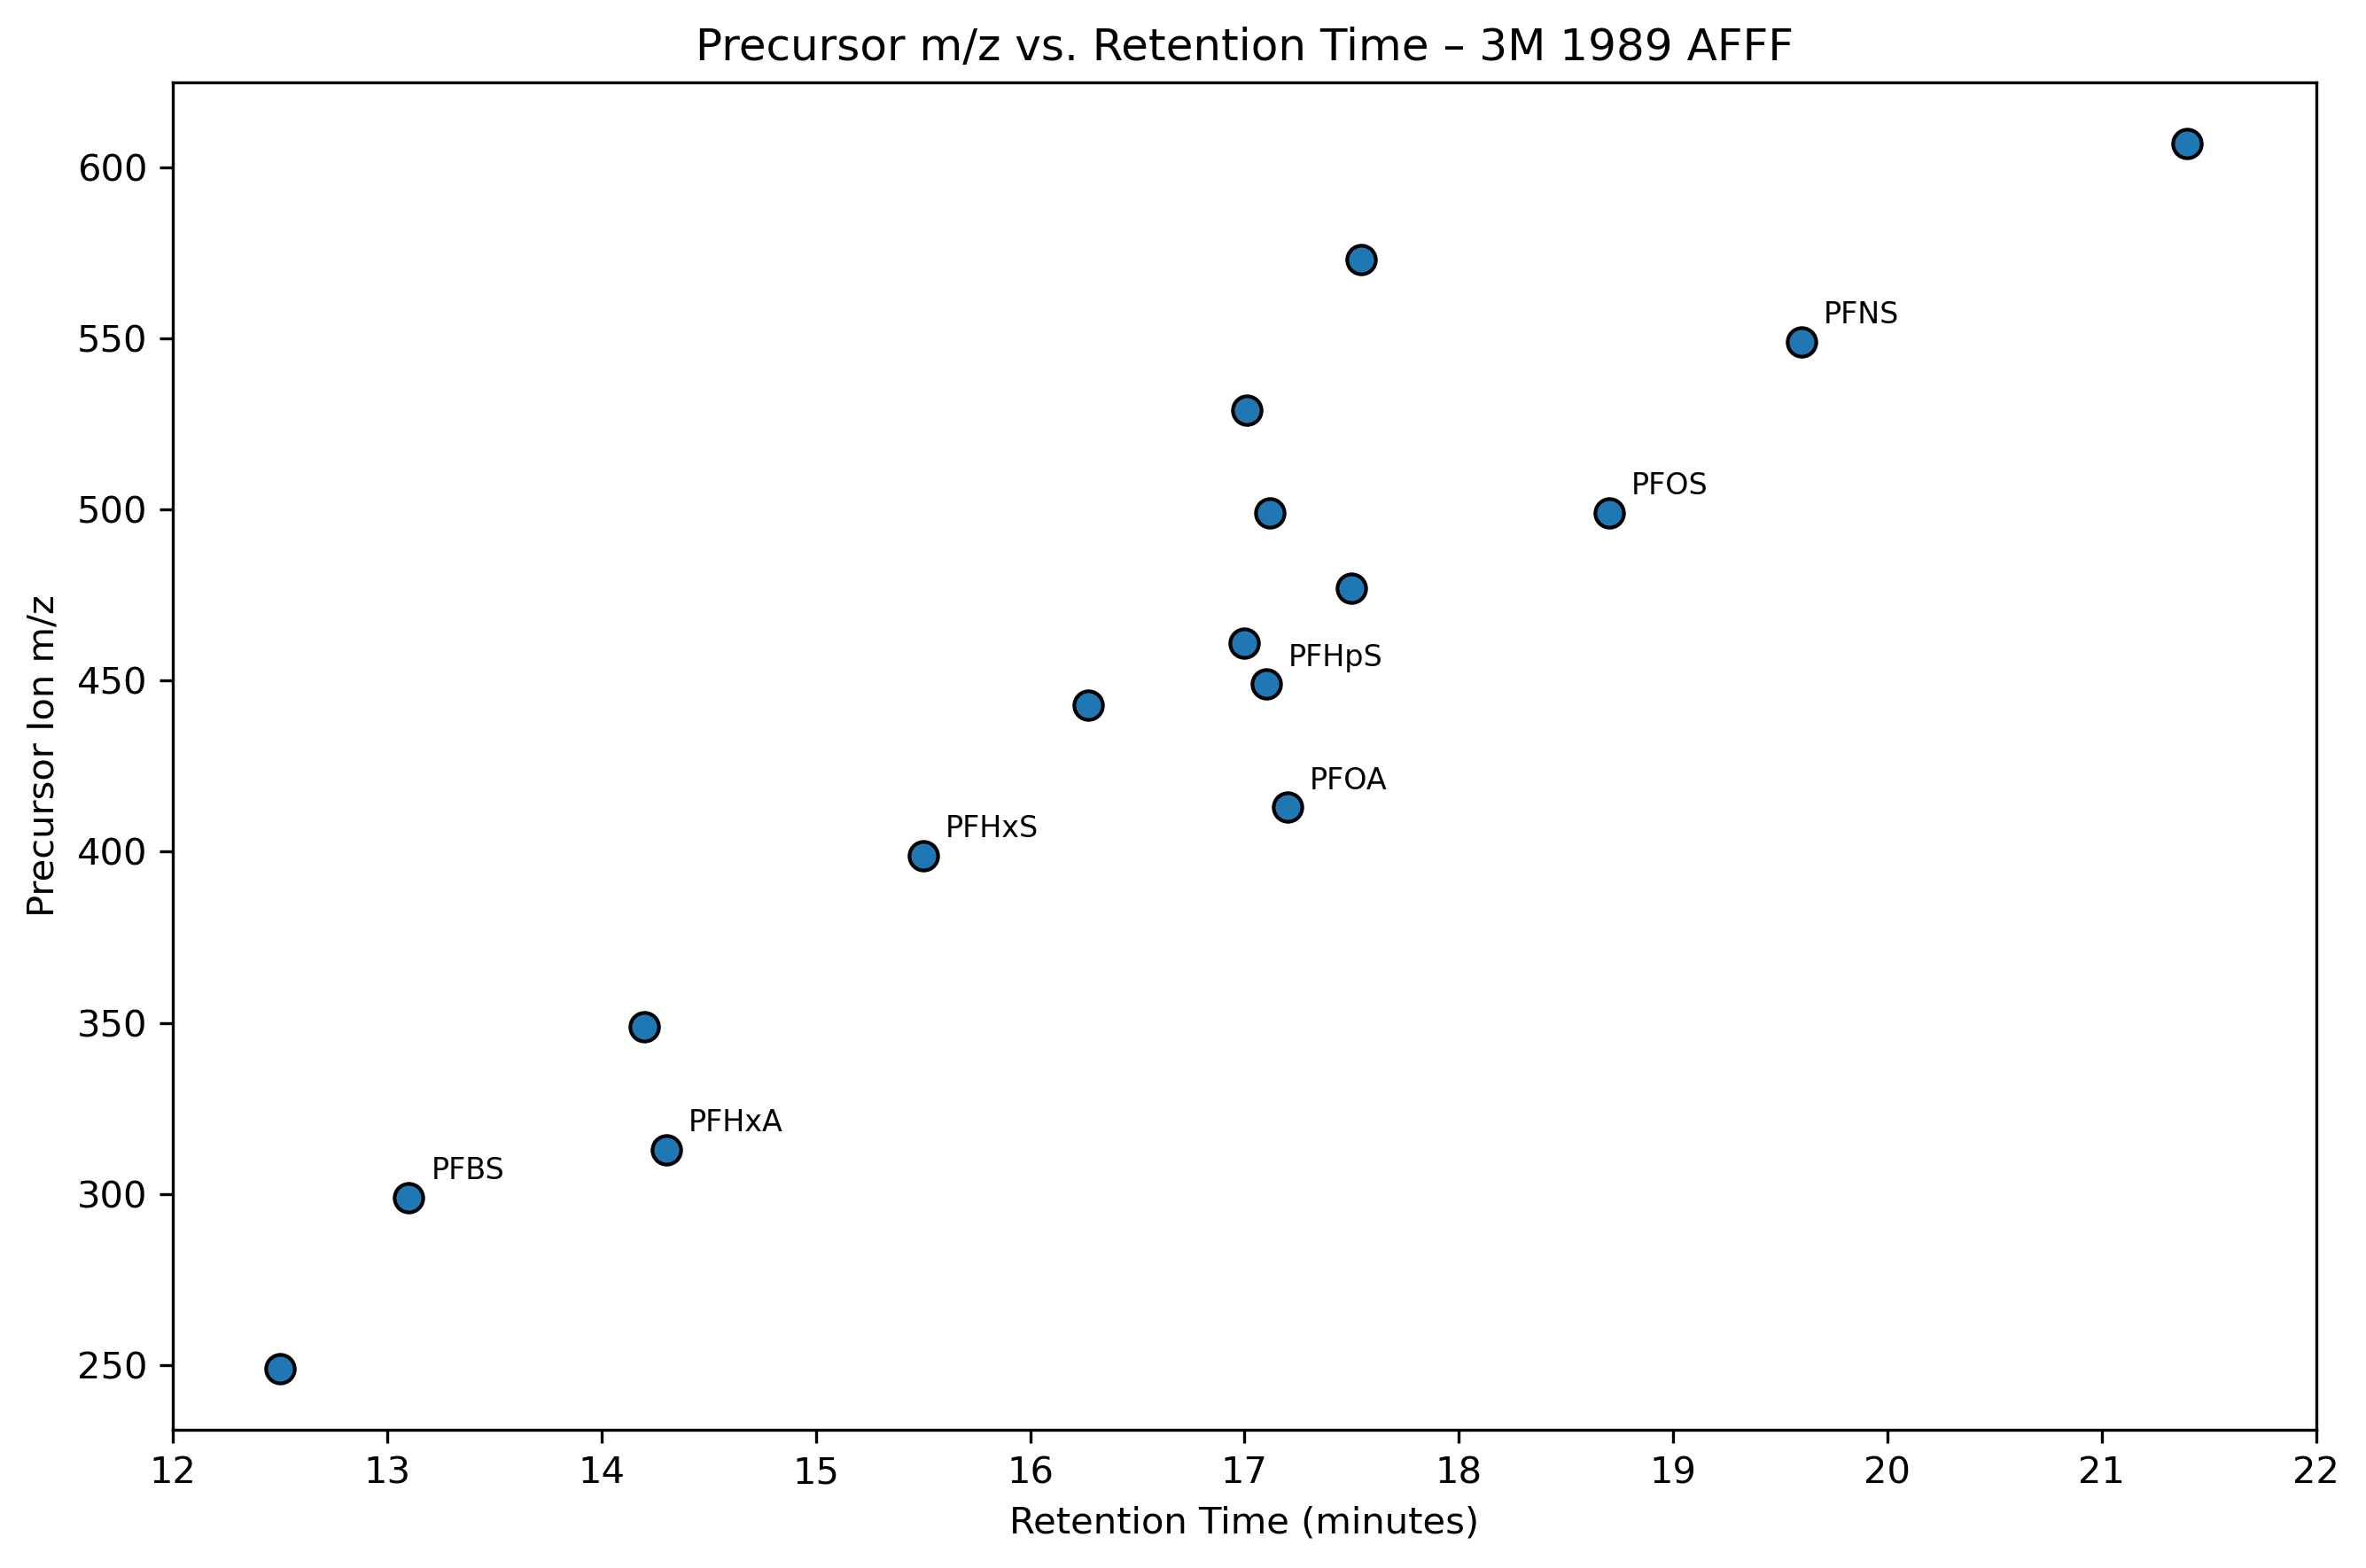

In [100]:
# Plot precursor m/z against chromatographic retention time

labels = {
    "Perfluorobutanesulfonic acid": "PFBS",
    "Perfluorohexanoic acid": "PFHxA",
    "Perfluorohexanesulfonic acid": "PFHxS",
    "Perfluorooctanoic acid": "PFOA",
    "Perfluoroheptanesulfonic acid": "PFHpS",
    "Perfluorooctanesulfonic acid": "PFOS",
    "Perfluorononanesulfonic acid": "PFNS"
}

plt.figure(figsize=(9,6), dpi=300)

plt.scatter(
    sample_df["Retention Time"],
    sample_df["Precursor m/z"],
    s=60,
    edgecolor="black"
)

for _, row in sample_df.iterrows():
    if row["Compound"] in labels:
        plt.annotate(
            labels[row["Compound"]],
            (row["Retention Time"], row["Precursor m/z"]),
            xytext=(6,5),
            textcoords="offset points",
            fontsize=8
        )

plt.title(f"Precursor m/z vs. Retention Time – {selected_sample}")
plt.xlabel("Retention Time (minutes)")
plt.ylabel("Precursor Ion m/z")

# Increase retention-time axis resolution
plt.xticks(np.arange(12, 23, 1))

plt.tight_layout()
plt.show()

#### c) Short- and Long-Chain PFAA Composition

In [101]:
# Classify PFCAs and PFSAs by carbon-chain length
short_chain = {
    "Perfluorohexanoic acid": "PFHxA",           # C6 PFCA
    "Perfluoropropane sulfonate": "PFPrS",       # C3 PFSA
    "Perfluorobutanesulfonic acid": "PFBS",      # C4 PFSA
    "Perfluoropentanesulfonic acid": "PFPeS"     # C5 PFSA
}
long_chain = {
    "Perfluorooctanoic acid": "PFOA",            # C8 PFCA
    "Perfluorohexanesulfonic acid": "PFHxS",     # C6 PFSA
    "Perfluoroheptanesulfonic acid": "PFHpS",    # C7 PFSA
    "Perfluorooctanesulfonic acid": "PFOS",      # C8 PFSA
    "Perfluorononanesulfonic acid": "PFNS"       # C9 PFSA
}

# Assign chain classification
def classify_chain(compound):
    if compound in short_chain:
        return "Short-chain"
    elif compound in long_chain:
        return "Long-chain"
    else:
        return "Other / not classified"
sample_df["Chain Classification"] = (
    sample_df["Compound"].apply(classify_chain)
)

# Count compounds in each category
chain_counts = (
    sample_df["Chain Classification"]
    .value_counts()
    .reindex(
        ["Short-chain", "Long-chain", "Other / not classified"],
        fill_value=0
    )
    .reset_index()
)
chain_counts.columns = [
    "Chain Classification",
    "Number of Compounds"
]

chain_counts["Percentage"] = (
    chain_counts["Number of Compounds"] / len(sample_df) * 100
).round(1)

chain_counts["Percentage"] = (
    chain_counts["Percentage"].astype(str) + "%"
)

display(chain_counts)

,Chain Classification,Number of Compounds,Percentage
0,Short-chain,4,25.0%
1,Long-chain,5,31.2%
2,Other / not classified,7,43.8%


The 3M 1989 AFFF sample contained 16 identified PFAS compounds, including commonly studied compounds such as PFOS, PFOA, PFHxS, PFHxA, and PFBS. Precursor m/z values ranged from approximately 249 to 607, while retention times ranged from 12.5 to 21.4 minutes, with higher-mass compounds generally appearing at longer retention times. Of the 16 compounds, 25.0% were classified as short-chain PFAAs (4) and 31.3% as long-chain PFAAs (5), while 43.8% fell outside the PFCA/PFSA chain-length classification (7). 

Overall, examining an individual sample provides a closer look at its specific PFAS composition and analytical characteristics that may be less apparent when considering the database as a whole.

### 2.2.5 Sample-Level Feature Table

In [102]:
import pandas as pd

cursor.execute("""
SELECT
    s.description AS sample,
    COUNT(DISTINCT c.id) AS compound_count,
    ROUND(AVG(p.precursor_mz),2) AS avg_precursor_mz,
    ROUND(MIN(p.precursor_mz),2) AS min_precursor_mz,
    ROUND(MAX(p.precursor_mz),2) AS max_precursor_mz,
    ROUND(AVG(p.rt_centroid),2) AS avg_retention_time
FROM samples s
JOIN peaks p
    ON s.id = p.sample_id
JOIN compound_fragments cf
    ON p.id = cf.peak_id
JOIN compounds c
    ON cf.compound_id = c.id
GROUP BY
    s.description
ORDER BY
    compound_count DESC;
""")

sample_summary = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "Sample",
        "Compound Count",
        "Avg m/z",
        "Min m/z",
        "Max m/z",
        "Avg Retention Time (min)"
    ]
)

sample_summary

sample_summary.head(10)

,Sample,Compound Count,Avg m/z,Min m/z,Max m/z,Avg Retention Time (min)
0,Reference Standard for PFAS,36,486.02,228.97,712.95,13.30
1,3M FC-95 Formulation,31,495.32,198.95,710.92,18.22
2,3M PFOS Technical Mixture,29,470.55,198.95,610.92,17.72
3,3M 1993b AFFF,19,423.00,248.95,571.09,15.89
4,3M 2001 AFFF,17,431.25,248.95,557.07,16.24
5,3M 1998 AFFF,17,422.31,248.95,557.07,15.85
6,3M 1989 AFFF,16,468.14,248.95,606.90,17.35
7,3M 1993a AFFF,15,423.37,248.95,571.09,15.78
8,AFFF Reserve Tank,10,466.18,298.94,548.93,17.56
9,3M FC-129 Formulation,10,471.12,334.00,583.98,19.51


Results: The sample-level summary statistics reveal considerable variability in PFAS composition across the analyzed samples. The Reference Standard for PFAS contains the largest number of detected compounds (36), followed by the 3M FC-95 Formulation (31) and the 3M PFOS Technical Mixture (29). In contrast, many of the PFAS150 samples contain only a single detected compound, consistent with their role as individual reference materials.

Average precursor m/z values range from approximately 423 to 495 for the complex AFFF and formulation samples shown in Table 4.5, while the average chromatographic retention times range from approximately 13.3 to 19.5 minutes. The reported minimum and maximum precursor m/z values further demonstrate that these samples contain compounds spanning a broad molecular mass range.

Interpretation: This analysis highlights the chemical diversity present among the samples in the NIST PFAS database. Complex mixtures, such as the AFFF formulations and 3M products, contain numerous PFAS compounds distributed across a wide range of precursor masses, whereas individual reference standards are characterized by a single compound and therefore have identical minimum, maximum, and average m/z values.

From a data analysis perspective, these sample-level summary statistics provide a concise representation of each sample's chemical composition. Quantities such as compound count, average precursor m/z, and average retention time can serve as descriptive features for comparing samples and represent an initial step toward constructing sample-level feature tables for downstream exploratory analyses and machine learning applications.

### 2.2.6 Construct a Sample–Compound Feature Matrix

Objective: Construct a sample-by-compound feature matrix in which each row represents a sample and each column represents a PFAS compound. The matrix provides a binary representation of compound presence across samples and serves as a foundation for downstream co-occurrence analyses, clustering, and machine learning applications.

In [103]:
import pandas as pd

cursor.execute("""
SELECT DISTINCT
    s.description AS sample,
    c.name AS compound
FROM samples s
JOIN peaks p
    ON s.id = p.sample_id
JOIN compound_fragments cf
    ON p.id = cf.peak_id
JOIN compounds c
    ON cf.compound_id = c.id;
""")

df = pd.DataFrame(cursor.fetchall(), columns=["Sample", "Compound"])

# Construct the complete sample-compound feature matrix
feature_matrix = pd.crosstab(
    df["Sample"],
    df["Compound"]
).astype(int)

# Select the 10 most frequently detected compounds
top_compounds = feature_matrix.sum().sort_values(ascending=False).head(10).index

# Create a display matrix containing the top compounds
display_matrix = feature_matrix[top_compounds]

# Rename common PFAS compounds using standard abbreviations
display_matrix = display_matrix.rename(columns={
    "Perfluorooctanesulfonic acid": "PFOS",
    "Perfluorohexanesulfonic acid": "PFHxS",
    "Perfluoroheptanesulfonic acid": "PFHpS",
    "Perfluorobutanesulfonic acid": "PFBS",
    "Perfluoropentanesulfonic acid": "PFPeS",
    "Perfluoropropane sulfonate": "PFPrS",
    "Perfluorohexanoic acid": "PFHxA",
    "Perfluorooctanoic acid": "PFOA"
})

# Remove the column index label
display_matrix.columns.name = None

display_matrix

,PFOA,PFOS,PFHxS,PFHpS,PFBS,PFHxA,PFPeS,PFPrS,"(6E)-1,1,2,2,3,3,4,4,5,5,6,7,8,8,8-pentadecafluorooct-6-ene-1-sulfonic acid",Keto-perfluorooctane sulfonate
Sample,,,,,,,,,,
3M 1988 AFFF,0,0,0,0,0,0,0,0,0,0
3M 1989 AFFF,1,1,1,1,1,1,1,1,1,1
3M 1993a AFFF,1,1,1,1,1,1,1,1,1,0
3M 1993b AFFF,1,1,1,1,1,1,1,1,1,1
3M 1998 AFFF,1,1,1,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
PFAS150 - DTXSID90382620,0,0,0,0,0,0,0,0,0,0
PFAS150 - DTXSID9059832,0,0,0,0,0,0,0,0,0,0
PFAS150 - DTXSID9065443,0,0,0,0,0,0,0,0,0,0


A binary sample–compound feature matrix was generated using the ten most frequently detected PFAS compounds. Each row represents a sample, each column represents a compound, and the values indicate whether a compound is present (1) or absent (0). Standard PFAS abbreviations were used where applicable to improve readability.

Some results include:
- The 3M 1989 AFFF sample contains all ten displayed compounds.
- The Reference Standard for PFAS contains several of the most common compounds but not all of them.
- Many PFAS150 reference compounds contain none of these ten compounds.

The feature matrix provides a simplified view of which PFAS compounds (horizontal columns) are present in each sample (vertical row), allowing samples to be compared based on their detected compounds.

### 2.2.7 Compound co-occurence

In [104]:
top_co_occurrence = (
    feature_matrix[top_compounds]
    .T
    .dot(feature_matrix[top_compounds])
)

top_co_occurrence

Compound,Perfluorooctanoic acid,Perfluorooctanesulfonic acid,Perfluorohexanesulfonic acid,Perfluoroheptanesulfonic acid,Perfluorobutanesulfonic acid,Perfluorohexanoic acid,Perfluoropentanesulfonic acid,Perfluoropropane sulfonate,"(6E)-1,1,2,2,3,3,4,4,5,5,6,7,8,8,8-pentadecafluorooct-6-ene-1-sulfonic acid",Keto-perfluorooctane sulfonate
Compound,,,,,,,,,,
Perfluorooctanoic acid,12,10,9,9,8,8,9,7,6,5
Perfluorooctanesulfonic acid,10,12,9,9,8,8,9,7,6,5
Perfluorohexanesulfonic acid,9,9,11,9,8,8,9,7,6,5
Perfluoroheptanesulfonic acid,9,9,9,10,8,8,9,7,6,5
Perfluorobutanesulfonic acid,8,8,8,8,10,7,8,6,6,5
Perfluorohexanoic acid,8,8,8,8,7,9,8,7,5,4
Perfluoropentanesulfonic acid,9,9,9,9,8,8,9,7,6,5
Perfluoropropane sulfonate,7,7,7,7,6,7,7,7,5,4
"(6E)-1,1,2,2,3,3,4,4,5,5,6,7,8,8,8-pentadecafluorooct-6-ene-1-sulfonic acid",6,6,6,6,6,5,6,5,6,5


A compound co-occurrence matrix was generated using the ten most frequently detected PFAS compounds. Each value represents the number of samples in which a pair of compounds was detected together. Diagonal values indicate the total number of samples in which each individual compound was detected.

- PFOA and PFOS were detected together in 10 samples, representing the most frequent compound pair in the dataset.
- PFOA, PFOS, PFHxS, PFHpS, and PFPeS were each detected together in 9 samples, indicating these compounds commonly co-occur across multiple samples.
- PFOA, PFOS, PFHxS, PFHpS, PFBS, and PFHxA showed co-occurrence counts ranging from 8–9 samples, suggesting these PFAS are often found together.
- Perfluoropropane sulfonate (PFPrS) co-occurred with the major PFAS compounds in 6–7 samples, indicating a more limited but still frequent presence.
- The less common compounds, (6E)-1,1,2,2,3,3,4,4,5,5,6,7,8,8,8-pentadecafluorooct-6-ene-1-sulfonic acid and Keto-perfluorooctane sulfonate, exhibited the lowest co-occurrence counts (4–6 samples), suggesting they are detected in a smaller subset of samples.

### 2.2.8 PFAS Composition by Sample Class

In [105]:
cursor.execute("""
SELECT
    nsc.name AS sample_class,
    COUNT(DISTINCT c.id) AS compound_count
FROM samples s
JOIN norm_sample_classes nsc
    ON s.sample_class_id = nsc.id
JOIN peaks p
    ON s.id = p.sample_id
JOIN compound_fragments cf
    ON p.id = cf.peak_id
JOIN compounds c
    ON cf.compound_id = c.id
GROUP BY
    s.description,
    nsc.name
ORDER BY
    nsc.name;
""")

df = pd.DataFrame(
    cursor.fetchall(),
    columns=["Sample Class", "Compound Count"]
)

# Rename analytical standards for clearer presentation
df["Sample Class"] = df["Sample Class"].replace(
    "analytical standard", "reference standard"
)

sample_class_summary = (
    df.groupby("Sample Class")["Compound Count"]
      .agg(["count", "mean", "min", "max"])
      .round(2)
      .rename(columns={
          "count": "Samples",
          "mean": "Average Compounds",
          "min": "Minimum",
          "max": "Maximum"
      })
)

sample_class_summary

,Samples,Average Compounds,Minimum,Maximum
Sample Class,,,,
aqueous film-forming foam (AFFF),12,10.00,2,19
commercial formulation,3,23.33,10,31
reference standard,61,1.57,1,36


Results:
- Three sample classes were represented in the dataset: reference standards (61 samples), AFFF (12 samples), and commercial formulations (3 samples).
- Commercial formulations contained the greatest number of detected PFAS compounds, averaging 23.33 compounds per sample.
- AFFF samples contained an average of 10.00 detected compounds per sample, indicating greater chemical complexity than reference standards.
- Reference standards were the most common sample class but contained the fewest detected compounds, averaging 1.57 compounds per sample.
- The range of detected compounds varied from 1–36 for reference standards, 2–19 for AFFF samples, and 10–31 for commercial formulations.

The results demonstrate that PFAS composition varies substantially among sample classes. Reference standards generally contain one or a small number of target compounds, resulting in low compound counts. In contrast, AFFF samples and commercial formulations are chemically complex mixtures containing a greater diversity of PFAS compounds. These findings highlight the influence of sample class on PFAS composition and further support the use of sample-level features for comparing different types of PFAS samples.

# 3 MASS SPECTRAL CHARACTERIZATION

## 3.1 Explore MS/MS data
## 3.2 Number of Fragment Ions per Spectrum
## 3.3 Fragment m/z distribution
## 3.4 Fragment intensity distribution
## 3.5 Example MS/MS spectrum

## 3.1 Explore MS/MS data

What mass spectral information is available for the detected PFAS compounds in the NIST PFAS database?

Before analyzing fragmentation patterns, it is important to examine the structure of the ms_data table. This section identifies the spectral variables available for each chromatographic peak and describes how the database stores complete mass spectra.

In [108]:
cursor.execute("""
SELECT
    peak_id,
    ms_n,
    scantime,
    base_ion,
    base_int,
    measured_mz,
    measured_intensity
FROM ms_data
LIMIT 1;
""")

df = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "Peak ID",
        "MS Level",
        "Scan Time",
        "Base Ion (m/z)",
        "Base Ion Intensity",
        "Measured m/z",
        "Measured Intensity"
    ]
)

df

,Peak ID,MS Level,Scan Time,Base Ion (m/z),Base Ion Intensity,Measured m/z,Measured Intensity
0,1,1,16.8224,529.0815,2311.1898,529.0815 530.0845 531.0778,2311.18977520742 125.047514101823 438.075452120501


Results
- A representative record from the ms_data table was examined to illustrate how mass spectral data are stored. The spectrum included the scan time, base ion m/z, and base ion intensity.
- The selected spectrum was associated with Peak ID 1 and was acquired at MS level 1 with a scan time of 16.8224 minutes.
- The spectrum had a base ion m/z of 529.0815 with a corresponding base ion intensity of 2311.1898.
- The measured m/z values and their corresponding intensities were stored as paired, space-separated lists within the measured_mz and measured_intensity columns.

Each row in the ms_data table represents one complete mass spectrum. Instead of storing each detected ion in a separate row, the database stores all ion masses and their corresponding intensities together, preserving the full spectral profile for each chromatographic peak. This organization makes it possible to analyze and compare PFAS mass spectra in later sections.

## 3.2 Number of Fragment Ions per Spectrum

How many fragment ions are detected in each mass spectrum?

This section quantifies the number of detected ions within each spectrum to characterize the complexity of the mass spectral data across the dataset.

Statistic,Value
Count,24451.000000
Mean,24.270000
Std. Dev.,30.760000
Minimum,1.000000
25th Percentile,10.000000
Median,18.000000
75th Percentile,29.000000
Maximum,998.000000


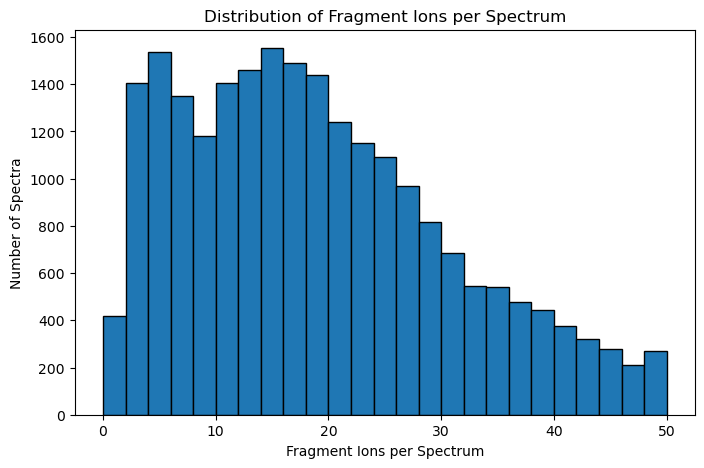

In [113]:
cursor.execute("""
SELECT
    peak_id,
    measured_mz
FROM ms_data
WHERE measured_mz IS NOT NULL;
""")

fragment_counts = pd.DataFrame(
    cursor.fetchall(),
    columns=["Peak ID", "Measured m/z"]
)

# Count the number of measured ions stored in each spectrum
fragment_counts["Fragment Count"] = (
    fragment_counts["Measured m/z"]
    .str.split()
    .str.len()
)

# Summary statistics
summary = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Std. Dev.",
        "Minimum",
        "25th Percentile",
        "Median",
        "75th Percentile",
        "Maximum"
    ],
    "Value": [
        len(fragment_counts),
        round(fragment_counts["Fragment Count"].mean(), 2),
        round(fragment_counts["Fragment Count"].std(), 2),
        int(fragment_counts["Fragment Count"].min()),
        int(fragment_counts["Fragment Count"].quantile(0.25)),
        int(fragment_counts["Fragment Count"].median()),
        int(fragment_counts["Fragment Count"].quantile(0.75)),
        int(fragment_counts["Fragment Count"].max())
    ]
})

display(summary.style.hide(axis="index"))

# Distribution of fragment ions per spectrum
plt.figure(figsize=(8, 5))

plt.hist(
    fragment_counts["Fragment Count"],
    bins=25,
    range=(0, 50),
    edgecolor="black"
)

plt.xlabel("Fragment Ions per Spectrum")
plt.ylabel("Number of Spectra")
plt.title("Distribution of Fragment Ions per Spectrum")

plt.show()

The histogram displays spectra containing up to 50 fragment ions for visualization purposes. A small number of spectra contained more than 50 fragment ions, with a maximum of 998.

Results
- A total of 24,451 mass spectra were analyzed.
- The spectra contained an average of 24.27 fragment ions (median = 18), with fragment counts ranging from 1 to 998 ions.
- As shown in Figure X, most spectra contained fewer than 30 fragment ions, while the frequency of spectra decreased as fragment counts increased, producing a right-skewed distribution.

Interpretation

The fragment ion count distribution indicates that most PFAS mass spectra are of relatively low to moderate complexity, containing fewer than 30 detected fragment ions. However, a small number of spectra contain substantially more fragment ions, reflecting greater spectral complexity and producing a right-skewed distribution. The variation in fragment counts highlights differences in fragmentation behavior across the PFAS compounds represented in the dataset.

## 3.3. Distribution of Fragment Ion m/z Values

What is the distribution of fragment ion mass-to-charge (m/z) values across the PFAS mass spectra?

This section characterizes the mass-to-charge (m/z) values of detected fragment ions to better understand the range and distribution of ions represented within the PFAS mass spectral dataset.

In [114]:
cursor.execute("""
SELECT
    measured_mz
FROM ms_data;
""")

rows = cursor.fetchall()

fragment_mz = []

for row in rows:
    if row[0]:
        fragment_mz.extend(
            float(mz)
            for mz in row[0].split()
        )

df_mz = pd.DataFrame(
    fragment_mz,
    columns=["Fragment m/z"]
)

df_mz.head()

,Fragment m/z
0,529.0815
1,530.0845
2,531.0778
3,529.0808
4,530.0835


In [115]:
#Summary statistics

df_mz = df_mz[df_mz["Fragment m/z"] > 0]

summary = pd.DataFrame({
    "Statistic": ["Count", "Mean", "Std. Dev.", "Minimum",
                  "25th Percentile", "Median",
                  "75th Percentile", "Maximum"],
    "Value": [
        len(df_mz),
        round(df_mz["Fragment m/z"].mean(),2),
        round(df_mz["Fragment m/z"].std(),2),
        round(df_mz["Fragment m/z"].min(),2),
        round(df_mz["Fragment m/z"].quantile(.25),2),
        round(df_mz["Fragment m/z"].median(),2),
        round(df_mz["Fragment m/z"].quantile(.75),2),
        round(df_mz["Fragment m/z"].max(),2)
    ]
})

display(summary)

,Statistic,Value
0,Count,593393.00
1,Mean,347.84
2,Std. Dev.,167.23
3,Minimum,50.00
4,25th Percentile,229.05
5,Median,362.94
6,75th Percentile,499.01
7,Maximum,1141.93


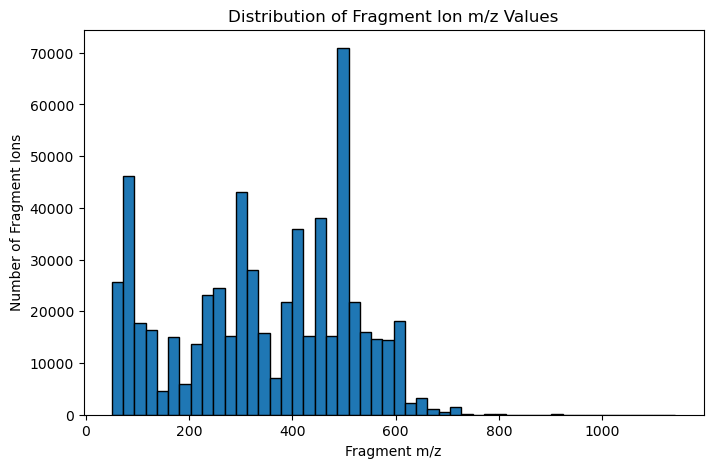

In [116]:
plt.figure(figsize=(8,5))

plt.hist(
    df_mz["Fragment m/z"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Fragment m/z")
plt.ylabel("Number of Fragment Ions")
plt.title("Distribution of Fragment Ion m/z Values")

plt.show()

A total of 593,403 fragment ions were extracted from the mass spectra. Fragment ion m/z values ranged from 0.00 to 1141.93, with a mean of 347.83 and a median of 362.94. The interquartile range extended from 229.05 to 499.01 m/z. As shown in Figure X, the majority of fragment ions were concentrated between approximately 200 and 600 m/z, with several prominent peaks observed throughout this range.

The distribution of fragment ion m/z values indicates that most detected fragments occur within the mid-mass range of the spectra rather than being uniformly distributed across all masses. The presence of multiple prominent peaks suggests that certain fragment ions are repeatedly observed across different PFAS compounds, reflecting common fragmentation behavior within the dataset.

## 3.4. Distribution of Fragment Ion Intensities

What is the distribution of fragment ion intensities across the PFAS mass spectra?

This section characterizes the intensity values of detected fragment ions to examine the distribution of signal abundances within the PFAS mass spectral dataset.

In [117]:
cursor.execute("""
SELECT
    measured_intensity
FROM ms_data;
""")

rows = cursor.fetchall()

fragment_intensity = []

for row in rows:
    if row[0]:
        fragment_intensity.extend(
            float(i)
            for i in row[0].split()
        )

df_intensity = pd.DataFrame(
    fragment_intensity,
    columns=["Fragment Intensity"]
)

In [118]:
summary = pd.DataFrame({
    "Statistic": ["Count", "Mean", "Std. Dev.", "Minimum",
                  "25th Percentile", "Median",
                  "75th Percentile", "Maximum"],
    "Value": [
        len(df_intensity),
        round(df_intensity["Fragment Intensity"].mean(),2),
        round(df_intensity["Fragment Intensity"].std(),2),
        round(df_intensity["Fragment Intensity"].min(),2),
        round(df_intensity["Fragment Intensity"].quantile(.25),2),
        round(df_intensity["Fragment Intensity"].median(),2),
        round(df_intensity["Fragment Intensity"].quantile(.75),2),
        round(df_intensity["Fragment Intensity"].max(),2)
    ]
})

display(summary)

,Statistic,Value
0,Count,5.934030e+05
1,Mean,4.864870e+05
2,Std. Dev.,9.027729e+06
3,Minimum,0.000000e+00
4,25th Percentile,1.986200e+02
5,Median,4.727680e+03
6,75th Percentile,2.967207e+04
7,Maximum,1.352521e+09


A histogram was not included because the fragment ion intensities span several orders of magnitude, resulting in an extremely right-skewed distribution. Standard and logarithmic visualizations provided limited additional insight beyond the descriptive statistics.

Results
- A total of 593,403 fragment ion intensities were analyzed.
- Fragment ion intensities ranged from 0.00 to 1.35 × 10⁹, with a mean intensity of 4.86 × 10⁵ and a median intensity of 4.73 × 10³.
- The middle 50% of fragment ion intensities ranged from 198.62 to 29,672.07.
- The large difference between the mean and median indicates that a relatively small number of fragment ions exhibited substantially higher signal intensities than the majority of observations.

Interpretation

Fragment ion intensities exhibit an extremely right-skewed distribution spanning several orders of magnitude. Most fragment ions have relatively low signal intensities, whereas a small number of highly abundant ions contribute disproportionately to the overall signal distribution. This broad dynamic range is characteristic of mass spectrometry data and reflects substantial variation in fragment ion abundance across the dataset.

## 3.5. Representative Mass Spectrum

What does a representative PFAS mass spectrum look like?

This section presents a representative mass spectrum to illustrate the relationship between fragment ion mass-to-charge (m/z) values and their corresponding signal intensities within an individual PFAS spectrum.

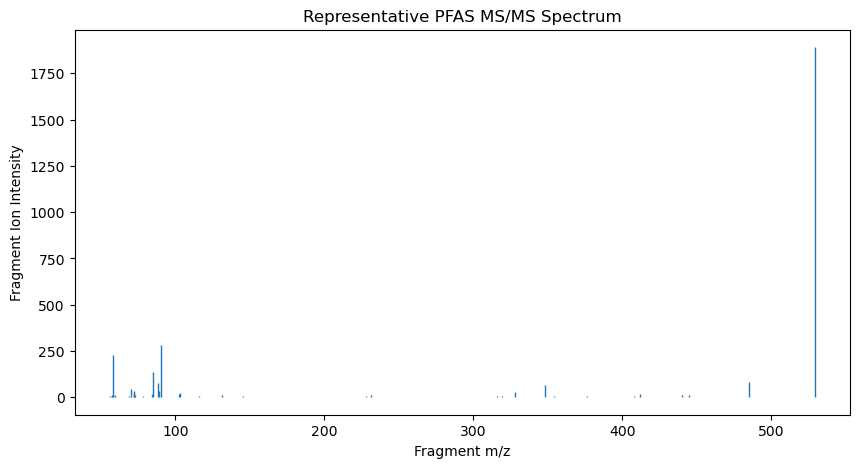

In [119]:
cursor.execute("""
SELECT
    peak_id,
    measured_mz,
    measured_intensity
FROM ms_data
WHERE LENGTH(measured_mz) - LENGTH(REPLACE(measured_mz, ' ', '')) >= 40
LIMIT 1;
""")

peak_id, mz_string, intensity_string = cursor.fetchone()

mz = [float(x) for x in mz_string.split()]
intensity = [float(x) for x in intensity_string.split()]

plt.figure(figsize=(10,5))

plt.vlines(
    mz,
    ymin=0,
    ymax=intensity,
    linewidth=1
)

plt.xlabel("Fragment m/z")
plt.ylabel("Fragment Ion Intensity")
plt.title("Representative PFAS MS/MS Spectrum")

plt.show()

Results
- A representative MS/MS spectrum was selected to illustrate the fragmentation data associated with a single chromatographic peak in the PFAS dataset.
- Each vertical peak in the spectrum represents a fragment ion produced during tandem mass spectrometry. The position of each peak along the x-axis corresponds to the fragment ion's mass-to-charge ratio (m/z), while the height of the peak represents its measured signal intensity.
- The representative spectrum contains multiple fragment ions spanning approximately 50–530 m/z, with one dominant peak near 529 m/z and numerous lower-intensity fragment ions distributed across the spectrum.
- Together, these peaks represent the fragmentation pattern of a single detected PFAS compound under the experimental conditions used to generate the database.

Interpretation
The representative spectrum provides a visual example of the MS/MS data analyzed throughout this notebook. Rather than producing a single signal, an individual PFAS compound fragments into multiple ions during tandem mass spectrometry, generating a characteristic fragmentation pattern. The combination of fragment ion masses (m/z) and their relative intensities forms a unique spectral fingerprint that can be used to compare, identify, and characterize PFAS compounds. This example illustrates the type of spectral information underlying the fragment count, m/z, and intensity analyses presented in the previous sections.

In [ ]:
# Conclusion